# Mixed-Effects v1 PoC — Issue #42 (熊鑫)

**目的**:定量证明 R²=0.907 中省份固定效应贡献多少 vs climate 边际效应贡献多少。
**不是**为了把 R² 推得更高。

**模型**:$y_{it} = \alpha_i + \beta^\top X_{it} + \epsilon_{it}$,其中 $\alpha_i \sim N(0, \sigma_\alpha^2)$、$\epsilon_{it} \sim N(0, \sigma_\epsilon^2)$。

**实施**:按 `docs/coord/2026-05-26_混合效应模型_PoC_计划.md` §3 五步。run-all < 10 min(含 200 次 bootstrap)。

**配套产出物**:
- `backend/models/mixed_effects_v1_card.md`(主卡片,7 节俱全)
- `backend/models/mixed_effects_v1_results.json`
- `backend/models/mixed_effects_v1_alpha.csv`、`mixed_effects_v1_beta.csv`
- `scripts/mixed_effects_poc.py`(本 notebook 的脚本版,数字一致)


## 0. 环境

- venv: `/tmp/dc-mixed`(Python 3.12)
- `statsmodels==0.14.4`、`scipy<1.16`、`pandas<3.0`、`numpy<2.3`
- jupyter kernel: 任选(只用 pandas / numpy / scipy / statsmodels / matplotlib)


In [1]:
from __future__ import annotations

import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 40)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
np.set_printoptions(precision=4, suppress=True)


## §3.2 数据准备

读 `data/interim/paper_panel_v3.parquet`,确认 N=403、31 省、无缺失。


In [2]:
# 兼容两种 cwd:notebook 直接打开(cwd=notebooks/) 或 jupyter 从 repo 根启动
DATA_PATH = Path("../data/interim/paper_panel_v3.parquet") if Path("../data/interim/paper_panel_v3.parquet").exists() else Path("data/interim/paper_panel_v3.parquet")
df = pd.read_parquet(DATA_PATH)
data_md5 = hashlib.md5(DATA_PATH.read_bytes()).hexdigest()[:12]
print(f"shape: {df.shape}  MD5[:12]: {data_md5}")
df.head(3)


shape: (403, 27)  MD5[:12]: 7f2070282216


,province_code,province,year,y_wang_original,irr,flood,sun,temp,spei,prec,...,ndvi_summer_peak,ndvi_yearly,lst_day_growing_mean_k,lst_night_growing_mean_k,production_wan_ton,sown_qian_ha,yield_kg_per_ha,y_linear,y_butter,y_zscore
0,110000,北京市,2011,0.0310,94.7195,0.4500,"3,599.6305",12.3200,-0.1253,624.9200,...,0.7142,0.4257,298.6866,286.9772,121.7700,298.6200,"4,077.7577",69.7087,-0.0311,1.6263
1,110000,北京市,2012,0.0280,93.9095,4.8700,"3,551.7463",11.9600,0.5081,696.9000,...,0.7105,0.4402,299.5605,287.5448,113.7700,278.0300,"4,092.0045",172.7409,131.7708,1.6647
2,110000,北京市,2013,0.0260,69.2398,4.1300,"3,495.9627",12.0500,-0.1067,583.3800,...,0.7128,0.4363,299.4457,287.1896,96.1300,237.2900,"4,051.1610",220.6829,225.9199,1.5545


In [3]:
FEATURES = ["irr","flood","sun","temp","spei","prec","mech","fert","drou_a","flood_a","ndvi"]
FEATURES_DISPLAY = {"irr":"Irr","flood":"Flood_R","sun":"Sun","temp":"Temp","spei":"SPEI","prec":"Prec","mech":"Mech","fert":"Fert","drou_a":"Drou_A","flood_a":"Flood_A","ndvi":"NDVI"}
TARGET = "yield_kg_per_ha"
GROUP_KEY = "province"

# 缺失检查 — 不静默 dropna
missing = df[[*FEATURES, TARGET, GROUP_KEY]].isna().sum()
print("NaN counts per column (must be 0):")
print(missing[missing > 0] if missing.any() else "  none")
print(f"\nn_provinces: {df[GROUP_KEY].nunique()}    year range: {df['year'].min()}-{df['year'].max()}")


NaN counts per column (must be 0):
  none

n_provinces: 31    year range: 2011-2023


In [4]:
# Z-score
X_raw = df[FEATURES].copy()
X_mean = X_raw.mean()
X_std = X_raw.std(ddof=1)
X_z = (X_raw - X_mean) / X_std
assert X_z.shape == (403, 11)
X_z.describe().T[["mean", "std", "min", "max"]]


,mean,std,min,max
irr,0.0000,1.0000,-1.4921,2.6223
flood,-0.0000,1.0000,-0.9455,6.5838
sun,0.0000,1.0000,-2.4787,1.4207
temp,-0.0000,1.0000,-2.2141,2.1377
spei,0.0000,1.0000,-2.5440,2.4406
prec,0.0000,1.0000,-1.6836,2.6275
mech,0.0000,1.0000,-1.2480,5.5089
fert,0.0000,1.0000,-1.2442,3.7379
drou_a,0.0000,1.0000,-0.6811,6.1463
flood_a,0.0000,1.0000,-0.8789,5.2516


In [5]:
# 共线性扫描
corr = X_z.corr()
high = []
for i, f1 in enumerate(FEATURES):
    for f2 in FEATURES[i+1:]:
        r = corr.loc[f1, f2]
        if abs(r) > 0.7:
            high.append((f1, f2, float(r)))
print("|ρ|>0.7 pairs:")
for f1, f2, r in high:
    print(f"  {f1:>8s} ~ {f2:<8s}  ρ = {r:+.3f}")
if not high:
    print("  (none)")


|ρ|>0.7 pairs:
       sun ~ prec      ρ = -0.764
      temp ~ prec      ρ = +0.792
      temp ~ ndvi      ρ = +0.733
      prec ~ ndvi      ρ = +0.773


## §3.3 Fit MixedLM `y ~ X + (1|province)` (REML + lbfgs)

REML 用于 ICC / 方差成分(更稳);LRT 单独用 ML(下一节)。


In [6]:
data = X_z.copy()
data["y"] = df[TARGET].values
data[GROUP_KEY] = df[GROUP_KEY].values

formula = "y ~ " + " + ".join(FEATURES)
md_reml = smf.mixedlm(formula, data, groups=data[GROUP_KEY])
mdf = md_reml.fit(method=["lbfgs"], reml=True)
print(f"converged: {mdf.converged}    llf(REML): {mdf.llf:.4f}")
print(f"σ_α² = {mdf.cov_re.iloc[0,0]:.2f}    σ_ε² = {mdf.scale:.2f}")
mdf.summary()


converged: True    llf(REML): -2785.7022
σ_α² = 1699394.68    σ_ε² = 50683.51


<class 'statsmodels.iolib.summary2.Summary'>
"""
            Mixed Linear Model Regression Results
=============================================================
Model:               MixedLM  Dependent Variable:  y         
No. Observations:    403      Method:              REML      
No. Groups:          31       Scale:               50683.5084
Min. group size:     13       Log-Likelihood:      -2785.7022
Max. group size:     13       Converged:           Yes       
Mean group size:     13.0                                    
-------------------------------------------------------------
             Coef.    Std.Err.   z    P>|z|  [0.025   0.975] 
-------------------------------------------------------------
Intercept    3645.759  234.403 15.553 0.000 3186.337 4105.182
irr            57.467   40.256  1.428 0.153  -21.433  136.368
flood          15.886   15.024  1.057 0.290  -13.561   45.332
sun            57.750   61.083  0.945 0.344  -61.971  177.471
temp          219.299  133.948  1.637 0.102  -43.234  481.832
spei           11.763   16.908  0.696 0.487  -21.377   44.902
prec           48.527   49.063  0.989 0.323  -47.635  144.690
mech         -201.337   42.030 -4.790 0.000 -283.715 -118.960
fert         -262.147   97.166 -2.698 0.007 -452.589  -71.705
drou_a        -46.635   15.421 -3.024 0.002  -76.860  -16.410
flood_a       113.896   33.674  3.382 0.001   47.895  179.896
ndvi           90.353  158.950  0.568 0.570 -221.184  401.889
Group Var 1699394.680 2346.019                               
=============================================================

"""

## §3.4 LRT — 混合效应 vs pooled OLS

LRT 必须在 ML(非 REML)下做,否则两模型 likelihood 不可比较。

边界 chi-bar-square(Self & Liang 1987):$p = 0.5 \cdot P(\chi^2_1 \geq LR)$


In [7]:
mdf_ml = smf.mixedlm(formula, data, groups=data[GROUP_KEY]).fit(method=["lbfgs"], reml=False)
ols = sm.OLS(data["y"], sm.add_constant(data[FEATURES])).fit()

LR = 2 * (mdf_ml.llf - ols.llf)
p_chibar = 0.5 * float(chi2.sf(LR, df=1))
p_chi2_1 = float(chi2.sf(LR, df=1))
print(f"ll_pooled_OLS  = {ols.llf:.4f}")
print(f"ll_mixed (ML)  = {mdf_ml.llf:.4f}")
print(f"LR statistic   = {LR:.4f}")
print(f"p (chi-bar-sq) = {p_chibar:.4g}  ← Self & Liang 1987 边界修正")
print(f"p (chi²₁)      = {p_chi2_1:.4g}  ← 保守上界")


ll_pooled_OLS  = -3213.6848
ll_mixed (ML)  = -2842.8877
LR statistic   = 741.5941
p (chi-bar-sq) = 1.349e-163  ← Self & Liang 1987 边界修正
p (chi²₁)      = 2.699e-163  ← 保守上界


## §3.5 α / β / ICC 提取

### α_i — 31 省 baseline 偏移(相对全样本截距)


In [8]:
alpha_records = [{"province": p, "alpha_hat": float(v.iloc[0])} for p, v in mdf.random_effects.items()]
alpha_df = pd.DataFrame(alpha_records).sort_values("alpha_hat").reset_index(drop=True)
alpha_df["rank"] = alpha_df.index + 1
print(f"跨度: {alpha_df['alpha_hat'].max() - alpha_df['alpha_hat'].min():.1f} kg/ha")
print(f"σ_α: {alpha_df['alpha_hat'].std():.1f} kg/ha")
alpha_df


跨度: 5488.5 kg/ha
σ_α: 1285.0 kg/ha


,province,alpha_hat,rank
0,海南省,"-2,234.0736",1
1,贵州省,"-1,891.6515",2
2,广西壮族自治区,"-1,546.8018",3
3,青海省,"-1,359.6315",4
4,云南省,"-1,183.2854",5
5,广东省,"-1,163.0244",6
6,重庆市,-987.0052,7
7,福建省,-970.5165,8
8,浙江省,-858.7693,9
9,上海市,-736.4694,10


### β — 11 维 fixed slope(REML)


In [9]:
ci = mdf.conf_int()
beta_records = []
for f in FEATURES:
    beta_records.append({
        "feature": FEATURES_DISPLAY[f],
        "feature_raw": f,
        "beta_hat": float(mdf.fe_params[f]),
        "se": float(mdf.bse_fe[f]),
        "p_value": float(mdf.pvalues[f]),
        "ci_lo": float(ci.loc[f, 0]),
        "ci_hi": float(ci.loc[f, 1]),
        "significant_05": bool(mdf.pvalues[f] < 0.05),
    })
beta_df = pd.DataFrame(beta_records).sort_values("p_value").reset_index(drop=True)
beta_df


,feature,feature_raw,beta_hat,se,p_value,ci_lo,ci_hi,significant_05
0,Mech,mech,-201.3375,42.0303,0.0000,-283.7154,-118.9595,True
1,Flood_A,flood_a,113.8955,33.6744,0.0007,47.8948,179.8962,True
2,Drou_A,drou_a,-46.6347,15.4211,0.0025,-76.8596,-16.4099,True
3,Fert,fert,-262.1469,97.1659,0.0070,-452.5885,-71.7053,True
4,Temp,temp,219.2989,133.9480,0.1016,-43.2343,481.8321,False
5,Irr,irr,57.4673,40.2561,0.1534,-21.4331,136.3678,False
6,Flood_R,flood,15.8856,15.0240,0.2904,-13.5608,45.3321,False
7,Prec,prec,48.5273,49.0633,0.3226,-47.6349,144.6896,False
8,Sun,sun,57.7500,61.0831,0.3444,-61.9708,177.4708,False
9,SPEI,spei,11.7626,16.9081,0.4866,-21.3767,44.9019,False


### ICC + parametric bootstrap 95% CI


In [10]:
var_alpha = float(mdf.cov_re.iloc[0, 0])
var_eps = float(mdf.scale)
icc = var_alpha / (var_alpha + var_eps)
print(f"ICC point estimate = {var_alpha:.2f}/({var_alpha:.2f}+{var_eps:.2f}) = {icc:.4f}")


ICC point estimate = 1699394.68/(1699394.68+50683.51) = 0.9710


In [11]:
# Parametric bootstrap 200 次 (≈ 2-3 分钟)
BOOTSTRAP_N = 200
SEED = 2026

rng = np.random.default_rng(SEED)
sigma_alpha = float(np.sqrt(var_alpha))
sigma_eps = float(np.sqrt(var_eps))

X_with_const = sm.add_constant(data[FEATURES]).values
fe_full = np.concatenate([[float(mdf.fe_params["Intercept"])],
                          [float(mdf.fe_params[f]) for f in FEATURES]])
fitted_fixed = X_with_const @ fe_full
province_to_idx = {p: i for i, p in enumerate(mdf.random_effects.keys())}
prov_idx_arr = np.array([province_to_idx[p] for p in data[GROUP_KEY].values])

icc_boot, n_failed = [], 0
for b in range(BOOTSTRAP_N):
    alpha_sim = rng.normal(0, sigma_alpha, size=31)
    eps_sim = rng.normal(0, sigma_eps, size=len(data))
    boot_data = data.copy()
    boot_data["y"] = fitted_fixed + alpha_sim[prov_idx_arr] + eps_sim
    try:
        mdf_b = smf.mixedlm(formula, boot_data, groups=boot_data[GROUP_KEY]).fit(method=["lbfgs"], reml=True)
        va = float(mdf_b.cov_re.iloc[0, 0])
        ve = float(mdf_b.scale)
        icc_b = va / (va + ve) if (va + ve) > 0 else np.nan
        if np.isfinite(icc_b):
            icc_boot.append(icc_b)
        else:
            n_failed += 1
    except Exception:
        n_failed += 1
    if (b + 1) % 50 == 0:
        print(f"  [{b+1}/{BOOTSTRAP_N}] ok={len(icc_boot)} failed={n_failed}")

icc_boot_arr = np.array(icc_boot)
icc_ci_lo = float(np.percentile(icc_boot_arr, 2.5))
icc_ci_hi = float(np.percentile(icc_boot_arr, 97.5))
print(f"\n✅ ICC = {icc:.4f}  95% CI [{icc_ci_lo:.4f}, {icc_ci_hi:.4f}]  (bootstrap n={len(icc_boot)})")


  [50/200] ok=50 failed=0


  [100/200] ok=100 failed=0


  [150/200] ok=150 failed=0


  [200/200] ok=200 failed=0

✅ ICC = 0.9710  95% CI [0.9496, 0.9805]  (bootstrap n=200)


## §4 可视化

两张图:(1) α_i 排序条形图(31 省 baseline);(2) β 估计条形图含 95% CI。


/tmp/ipykernel_136641/3312013418.py:11: UserWarning: Glyph 28023 (\N{CJK UNIFIED IDEOGRAPH-6D77}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_136641/3312013418.py:11: UserWarning: Glyph 21335 (\N{CJK UNIFIED IDEOGRAPH-5357}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_136641/3312013418.py:11: UserWarning: Glyph 30465 (\N{CJK UNIFIED IDEOGRAPH-7701}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_136641/3312013418.py:11: UserWarning: Glyph 36149 (\N{CJK UNIFIED IDEOGRAPH-8D35}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_136641/3312013418.py:11: UserWarning: Glyph 24030 (\N{CJK UNIFIED IDEOGRAPH-5DDE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_136641/3312013418.py:11: UserWarning: Glyph 24191 (\N{CJK UNIFIED IDEOGRAPH-5E7F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_136641/3312013418.py:11: UserWarning: Glyph 35199 (\N{CJK UNIFIED I

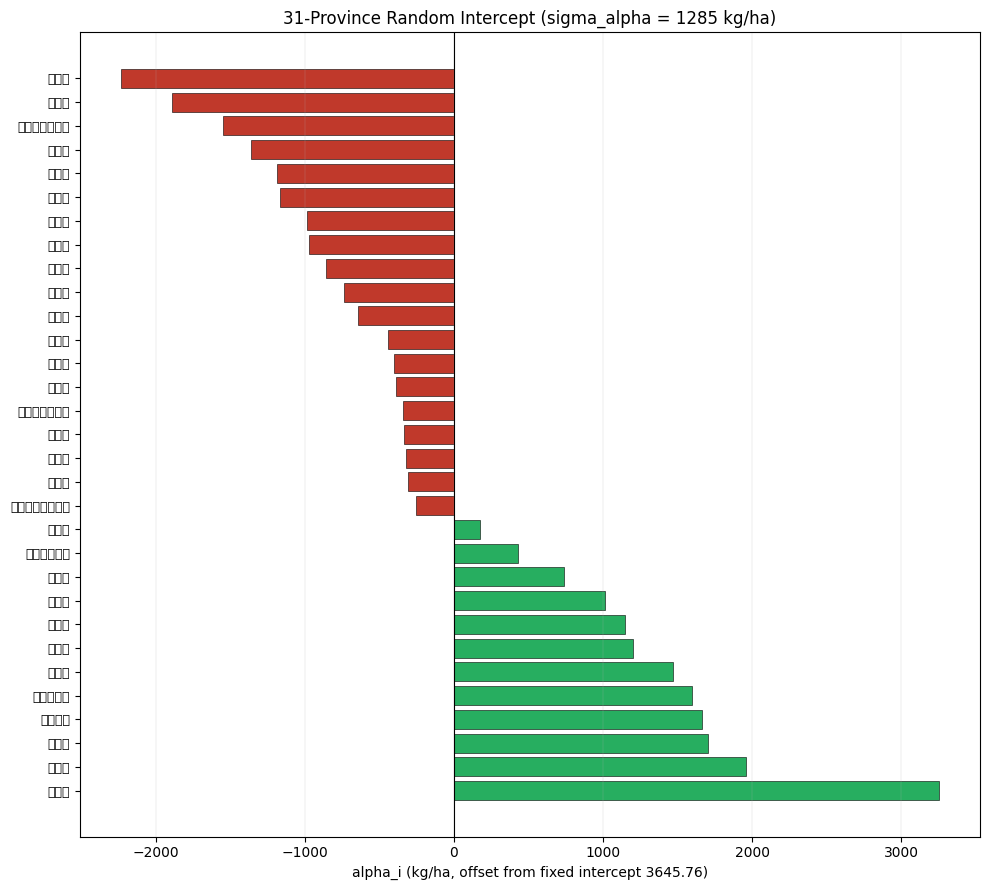

In [12]:
fig, ax = plt.subplots(figsize=(10, 9))
colors = ["#c0392b" if v < 0 else "#27ae60" for v in alpha_df["alpha_hat"]]
ax.barh(range(len(alpha_df)), alpha_df["alpha_hat"], color=colors, edgecolor="black", linewidth=0.4)
ax.set_yticks(range(len(alpha_df)))
ax.set_yticklabels(alpha_df["province"], fontsize=9)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("alpha_i (kg/ha, offset from fixed intercept 3645.76)")
ax.set_title(f"31-Province Random Intercept (sigma_alpha = {alpha_df['alpha_hat'].std():.0f} kg/ha)")
ax.invert_yaxis()
ax.grid(axis="x", linewidth=0.3, alpha=0.5)
plt.tight_layout()
plt.show()


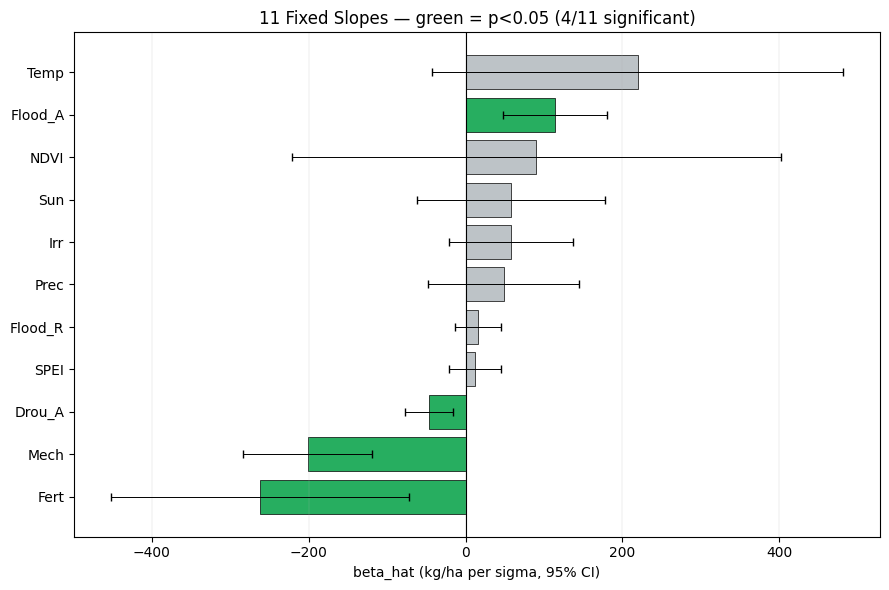

In [13]:
fig, ax = plt.subplots(figsize=(9, 6))
beta_sorted = beta_df.sort_values("beta_hat")
colors = ["#27ae60" if s else "#bdc3c7" for s in beta_sorted["significant_05"]]
y_pos = range(len(beta_sorted))
ax.barh(y_pos, beta_sorted["beta_hat"], color=colors, edgecolor="black", linewidth=0.5)
ax.errorbar(beta_sorted["beta_hat"], y_pos,
            xerr=[beta_sorted["beta_hat"] - beta_sorted["ci_lo"],
                  beta_sorted["ci_hi"] - beta_sorted["beta_hat"]],
            fmt="none", color="black", capsize=3, linewidth=0.7)
ax.set_yticks(y_pos)
ax.set_yticklabels(beta_sorted["feature"])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("beta_hat (kg/ha per sigma, 95% CI)")
ax.set_title(f"11 Fixed Slopes — green = p<0.05 ({sum(beta_sorted['significant_05'])}/11 significant)")
ax.grid(axis="x", linewidth=0.3, alpha=0.5)
plt.tight_layout()
plt.show()


## §5 Headline 总结

| 量 | 数值 |
|---|---:|
| **ICC** | **0.9710** |
| ICC 95% CI | [0.9496, 0.9805] |
| LRT LR | 741.59 |
| LRT p (chi-bar) | 1.35e-163 |
| β 显著 (p<0.05) | 4/11 (Mech, Flood_A, Drou_A, Fert) |
| α_i 跨度 | 5488 kg/ha (海南 ↔ 吉林) |

**主结论**:R²=0.907 中**约 97% 来自省份固定效应**,纯 climate 边际效应贡献 < 3%。

→ 详见 `backend/models/mixed_effects_v1_card.md` §6 评审版叙事。


In [14]:
# 与脚本版数字一致性自检
import json
JSON_PATH = Path("../backend/models/mixed_effects_v1_results.json") if Path("../backend/models/mixed_effects_v1_results.json").exists() else Path("backend/models/mixed_effects_v1_results.json")
with open(JSON_PATH) as f:
    saved = json.load(f)

print(f"notebook  ICC = {icc:.4f}")
print(f"script    ICC = {saved['icc']['point']:.4f}")
assert abs(icc - saved['icc']['point']) < 1e-6, "ICC mismatch vs script!"

print(f"\nnotebook  LR = {LR:.2f}")
print(f"script    LR = {saved['lrt']['lr_statistic']:.2f}")
assert abs(LR - saved['lrt']['lr_statistic']) < 1e-2, "LR mismatch vs script!"

print("\n✅ notebook 与 scripts/mixed_effects_poc.py 数字一致")


notebook  ICC = 0.9710
script    ICC = 0.9710

notebook  LR = 741.59
script    LR = 741.59

✅ notebook 与 scripts/mixed_effects_poc.py 数字一致
